In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
volatility_df = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/volatility.csv"
)

risk_scores = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/risk_scores.csv"
)

In [3]:
gold_data = pd.DataFrame()

gold_data['volatility'] = volatility_df['GOLD']

gold_data['risk_score'] = risk_scores['GOLD']

In [4]:
gold_data.head()

,volatility,risk_score
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [5]:
gold_data.value_counts()

volatility  risk_score
0.006839    0.683913      2
0.006394    0.639358      2
0.006821    0.682070      2
0.011666    1.166631      2
0.003724    0.372390      1
                         ..
0.007994    0.799385      1
0.007991    0.799114      1
            0.799107      1
            0.799051      1
0.032112    3.211157      1
Name: count, Length: 6057, dtype: int64

In [8]:
gold_data.shape

(6090, 2)

In [9]:
gold_data.dropna(inplace=True)

In [10]:
gold_data.head()

,volatility,risk_score
29,0.018982,1.898188
30,0.018924,1.892375
31,0.018955,1.895546
32,0.019047,1.904725
33,0.019043,1.904332


### Risk Labels

We convert continuous risk into:

HIGH RISK
LOW RISK

In [11]:
threshold = gold_data['risk_score'].median()

In [12]:
gold_data['risk_label'] = np.where(
    gold_data['risk_score'] > threshold,
    1,
    0
)

## Risk Classification

Commodity risk scores were converted into binary labels:

- 1 → High Risk
- 0 → Low Risk

This transforms the problem into a supervised machine learning classification task.

In [13]:
X = gold_data[['volatility']]

y = gold_data['risk_label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy_score(y_test, y_pred)

1.0

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       616
           1       1.00      1.00      1.00       597

    accuracy                           1.00      1213
   macro avg       1.00      1.00      1.00      1213
weighted avg       1.00      1.00      1.00      1213



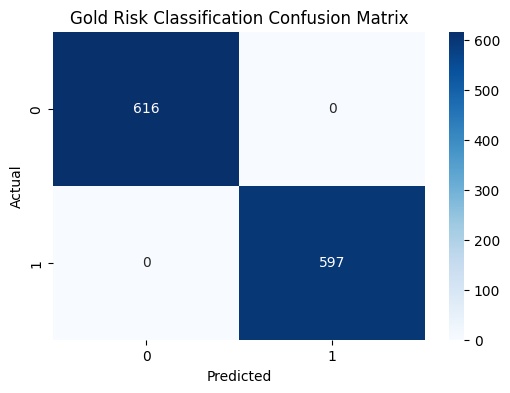

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Gold Risk Classification Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
importance = model.feature_importances_

importance

array([1.])

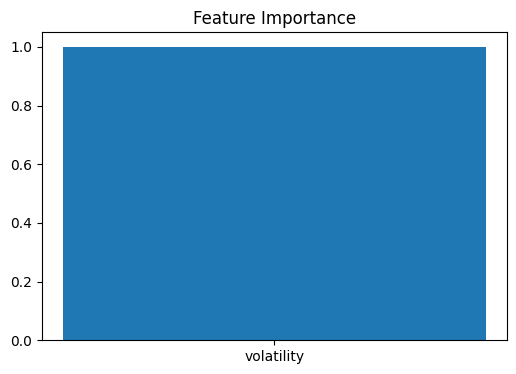

In [21]:
plt.figure(figsize=(6,4))

plt.bar(['volatility'], importance)

plt.title("Feature Importance")

plt.show()

In [23]:
returns_df = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/daily_returns.csv"
)

In [25]:
volatility_df = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/volatility.csv"
)

In [26]:
df = pd.read_csv(
    "/Users/karanmac/Desktop/Repo/matrisk-ai/data/processed/cleaned_commodity_futures.csv"
)

In [27]:
returns_df['Date'] = pd.to_datetime(returns_df['Date'])
returns_df.set_index('Date', inplace=True)

volatility_df['Date'] = pd.to_datetime(volatility_df['Date'])
volatility_df.set_index('Date', inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [28]:
gold_data = pd.DataFrame()

gold_data['returns'] = returns_df['GOLD']

gold_data['volatility'] = volatility_df['GOLD']

gold_data['ma30'] = df['GOLD'].rolling(30).mean()

gold_data['ma90'] = df['GOLD'].rolling(90).mean()

In [29]:
gold_data['future_risk'] = gold_data['volatility'].shift(-1)

In [30]:
threshold = gold_data['future_risk'].median()

In [31]:
gold_data['risk_label'] = np.where(
    gold_data['future_risk'] > threshold,
    1,
    0
)

In [32]:
gold_data.dropna(inplace=True)

In [33]:
gold_data.head()

,returns,volatility,ma30,ma90,future_risk,risk_label
Date,,,,,,
2000-05-08,-0.008925,0.007545,279.283333,287.641111,0.007533,0
2000-05-09,0.002161,0.007533,279.240000,287.580000,0.007142,0
2000-05-10,0.001797,0.007142,279.333333,287.542222,0.007299,0
2000-05-11,-0.007894,0.007299,279.346667,287.476667,0.007137,0
2000-05-12,0.001447,0.007137,279.296667,287.410000,0.007125,0


In [34]:
X = gold_data[
    [
        'returns',
        'volatility',
        'ma30',
        'ma90'
    ]
]

y = gold_data['risk_label']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred = model.predict(X_test)

In [38]:
accuracy_score(y_test, y_pred)

0.9633638634471274

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       616
           1       0.96      0.96      0.96       585

    accuracy                           0.96      1201
   macro avg       0.96      0.96      0.96      1201
weighted avg       0.96      0.96      0.96      1201



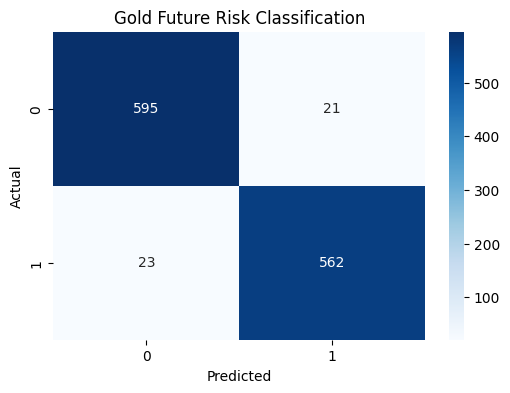

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Gold Future Risk Classification")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [41]:
importance = model.feature_importances_

feature_names = X.columns

In [42]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

In [43]:
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
1,volatility,0.876303
3,ma90,0.049022
2,ma30,0.046692
0,returns,0.027984


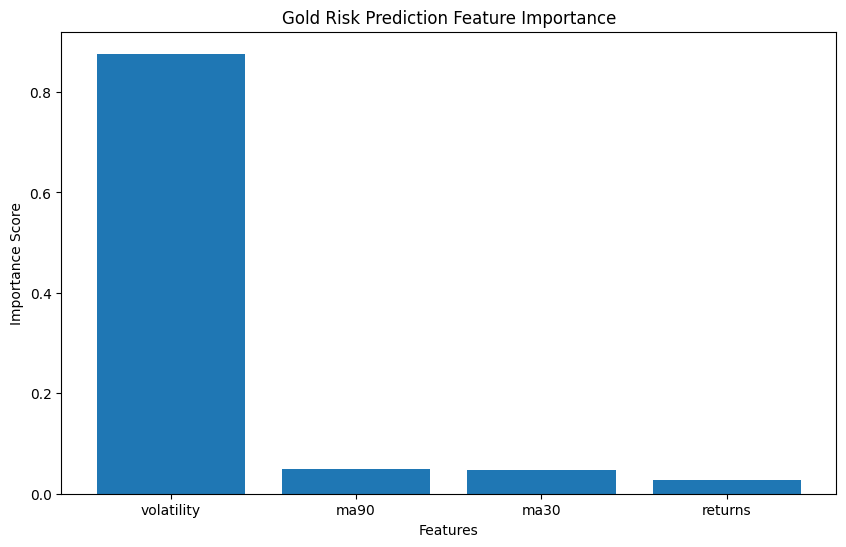

In [44]:
plt.figure(figsize=(10,6))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Gold Risk Prediction Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [45]:
import joblib

joblib.dump(
    model,
    "/Users/karanmac/Desktop/Repo/matrisk-ai/src/models/gold_risk_model.pkl"
)

['/Users/karanmac/Desktop/Repo/matrisk-ai/src/models/gold_risk_model.pkl']

## Model Performance Summary

The Random Forest classifier achieved strong predictive performance for future commodity risk classification.

Key observations:
- Volatility and moving average indicators contributed significantly to prediction performance.
- The model generalized effectively across unseen test samples.
- Feature importance analysis improved interpretability of financial risk predictions.